# Projet APR - Pricer de substitution & extraction des Greeks par différentiation automatique
### Entraînement sur prix d'options réels, comparaison à Black-Scholes et au marché


Réalisé par Kim TRINH


Dans ce projet, nous entraînons un réseau de neurones à approximer le prix d'une option à partir de prix de marché réellement observés. Nous comparons ensuite ce pricer à Black-Scholes, tous deux avec les mêmes variables d'entrées, et nous évaluons les deux approches par rapport au prix de marché réellement coté, sur une période que le réseau n'a jamais vue à l'entraînement. Nous extrayons enfin les Greeks du réseau par différentiation automatique à l'aide de `tf.GradientTape` (TP2), et nous vérifions si le réseau a appris, à partir des seuls prix, la structure de smile de volatilité que Black-Scholes ne capture pas.

# Plan du notebook

## I - Préparation des données
- **Partie I** - Imports et hyperparamètres
- **Partie II** - Collecte et traitement des données réelles
- **Partie III** - Première visualisation des données brutes
- **Partie IV** - Normalisation et préparation des tenseurs
## II - Construction du modèle
- **Partie V** - Entraînement du pricer MLP
## III - Evaluation et comparaison à l'aide de Black-Scholes
- **Partie VI** - Pricing Black-Scholes sur le jeu de test
- **Partie VII** - Comparaison tripartite : MLP · Black-Scholes · prix de marché
## IV - Analyse des résultats obtenus 
- **Partie VIII** - Extraction des Greeks par différentiation automatique
- **Partie IX** - Le pricer a-t-il appris le smile de volatilité ?
- **Partie X** - Bilan et analyse complète des résultats


# Partie I - Imports et hyperparamètres


Nous commençons par rassembler tous les imports nécessaires au projet.

In [1]:
import os, io, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

print('TensorFlow', tf.__version__)


TensorFlow 2.21.0


Nous fixons une graine aléatoire globale. Cela rend le projet entièrement reproductible : deux exécutions successives donneront exactement les mêmes poids de réseau et donc les mêmes résultats chiffrés.

In [2]:
GRAINE = 42
np.random.seed(GRAINE)
tf.random.set_seed(GRAINE)

# Mon ordinateur personnel est équipé d'un ryzen 5 de 6 coeurs... Et comme l'entraînement
# prend un certain temps, j'aimerais pouvoir être en mesure de l'utiliser en même temps
# d'où l'idée de limiter l'usage de coeurs possibles...

tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(4)
print('Configuration CPU appliquée.')


Configuration CPU appliquée.


Nous centralisons ensuite tous les réglages ici dans l'optique de ne pas avoir à parcourir tout le programme pour y réaliser des modifications au niveau des réglages (le nombre d'épochs et de batch notamment).

In [3]:
# On commence par collecter toutes les données qui nous intéressent (spot, prix des options, greeks, volatilité)
# qui sont contenues dans ce csv que l'on a trouvé sur Kaggle. 
# Malheuresement, les données date d'un peu... mais ça n'influe en rien sur la pertinence de notre projet

CHEMINS_CSV = {
    'SPY': 'spy_2020_2022.csv',
}
TICKERS = list(CHEMINS_CSV.keys())
NOMS_INDICE = {'SPY': 'S&P 500 (ETF SPDR)', 'QQQ': 'Nasdaq-100 (ETF Invesco)'}

# Ensuite, on découpe les données de telle sorte à réserver une section pour l'entrainement du modèle
# et une autre pour la tester et évaluer sa performance.

DATE_DEBUT_TRAIN = '2020-01-01'
DATE_FIN_TRAIN = '2021-12-31'
DATE_DEBUT_TEST = '2022-01-01'
DATE_FIN_TEST = '2022-12-31'

# On effectue également un léger filtre des données, pour écarter les "outliers"
MONEYNESS_MIN = 0.1
MONEYNESS_MAX = 1.9
DTE_MIN = 3 # jours : écarte le bruit de fin de vie et les contrats à 0 jour
DTE_MAX = 730
PRIX_MIN = 0.05 # écarte les contrats quasi sans valeur

# Puis on défini la volatilité réalisée du sous-jacent (dérivée du cours réel, fenêtre glissante) 
FENETRE_VOL_JOURS = 21    # ~1 mois de bourse
JOURS_BOURSE_AN = 252

# Enfin, on termine par collecter le taux sans risque réel, qui est donné par le prix des bons du Trésor US 3 mois,
# d'après ce qui est défini par convention en finance. 

# Clé API FRED (gratuite) – utilisée pour interroger l'endpoint officiel JSON
FRED_API_KEY = '36ead703826c33e853ccdeff963ff643'
URL_TAUX = (
    f'https://api.stlouisfed.org/fred/series/observations'
    f'?series_id=DGS3MO'
    f'&observation_start={DATE_DEBUT_TRAIN}'
    f'&observation_end={DATE_FIN_TEST}'
    f'&api_key={FRED_API_KEY}'
    f'&file_type=json'
)
TAUX_DEFAUT_ULTIME = 0.02   # filet de sécurité si même le repli mensuel est indisponible


Vient ensuite la configuration du réseau et de son entraînement, où l'on a réalisé deux choix importants.

**I - La maturité**

On a fait le choix de lui donner directement `sqrt_T` comme variable d'entrée, au lieu de T simple, car le prix d'une option ne dépend pas du temps restant de manière linéaire (c'est par ailleurs intégré dans la formule de Black Scholes). L'idée est d'aider à l'apprentissage du modèle.

**II - Le sous-échantillonage**

Mon PC étant de configuration relativement modeste, nous avons décidé de limiter le nombre de contrats utilisés dans l'apprentissage, avec `MAX_LIGNES_TRAIN`. Avec le nombre que l'on a choisi, la précision reste correcte malgré tout.

In [4]:
# Variables d'entrée du réseau
VARIABLES = ['S', 'K', 'T', 'sqrt_T', 'sigma', 'r', 'type_num']

# Architecture du MLP
NEURONES = 96 # largeur des couches cachées
NB_COUCHES = 4  # profondeur (un bon compromis capacité / coût CPU)
ACTIVATION = 'tanh' # activation lisse : indispensable pour un Gamma (dérivée 2nde) propre

# Entraînement, calibré pour mon potato PC (Ryzen 5, 16 Go, sans GPU)
LR = 1e-3
NB_EPOCHS = 60
TAILLE_BATCH = 2048
TAILLE_VAL = 0.15
PATIENCE = 8
MAX_LIGNES_TRAIN = 400_000

NB_POINTS_COURBE = 200
print('Hyperparamètres définis.')


Hyperparamètres définis.


# Partie II - Collecte et traitement des données réelles

**La principale difficulté technique du projet a été de trouver une source gratuite de cotations d'options réelles, complètes (tous strikes et toutes maturités) et sur plusieurs années.** 

yfinance ne nous permettait pas de collecter les données sur les options (call et put) sur une durée longue, et les autres API gratuites le permettant étaient très limités en termes de requêtes possibles. On a donc dû se rabattre sur un fichier CSV que l'on a trouvé sur Kaggle et qui rassemble un historique sur les options associées au S&P500 sur la période 2020-2022. Le défaut étant donc que l'on traite pas des dernières données disponibles en la matière.

**Nous avons pris deux précautions en matière de données données en entraînement pour garantir un résultat "non-tautologique"**

- Le réseau ne reçoit que `S`, `K`, `T`, `sigma` (volatilité réalisée du sous-jacent) et `r`, soit exactement les informations dont dispose Black-Scholes dans un usage classique (pricing d'options par un trader par exemple). La volatilité implicite de marché (`iv_marche`) n'est **jamais** utilisée comme entrée : par construction, c'est la volatilité qui fait coller Black-Scholes au prix observé, donc la donner au réseau reviendrait à lui souffler la réponse. Elle ne sert que de référence diagnostique (Parties III et IX).

- Le découpage train/test se fait par date (2020-2021 contre 2022), jamais en mélangeant aléatoirement les lignes : il s'agit d'un vrai test hors échantillon temporel.

**Nonobstant, nous avons dû faire une concession relativement importante (mais dont l'impact n'est pas non plus dramatique, comme on le verra juste après) pour Black-Scholes:** on se base sur des options américaines et avec dividendes, alors que Black-Scholes est surtout adaptée pour les options européennes (exerçables qu'à maturité) et sans dividendes. 
On a décidé de réaliser cette concession car il y a que très peu de données disponibles au grand public pour les marchés européennes (CAC40, etc.), et que même pour le marché américain ce n'était pas facile facile...

**Maintenant pour nos programmes**, nous commençons par définir une fonction de récupération du taux sans risque. Elle interroge la série officielle FRED (bons du Trésor US à 3 mois) et, en cas d'indisponibilité du réseau, on fait en sorte qu'elle se replie sur une approximation mensuelle codée en dur, sur un ordre de grandeur correct du taux 2020-2022, de telle sorte à ne pas bloquer le projet.

In [5]:
# Table de repli pour le taux sans risque, utilisée seulement si FRED est inaccessible.
# (taux quasi nul en 2020-2021, hausse marquée de la Fed en 2022)

TAUX_APPROX_2020_2022 = pd.DataFrame({
    'date': pd.to_datetime([
        '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
        '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020-12-01',
        '2021-01-01', '2021-04-01', '2021-07-01', '2021-10-01',
        '2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01',
        '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
    ]),
    'r': [
        0.0155, 0.0155, 0.0030, 0.0012, 0.0013, 0.0013,
        0.0012, 0.0011, 0.0011, 0.0010, 0.0009, 0.0008,
        0.0007, 0.0002, 0.0005, 0.0005,
        0.0019, 0.0033, 0.0052, 0.0077, 0.0095, 0.0166,
        0.0228, 0.0263, 0.0312, 0.0388, 0.0434, 0.0437,
    ],
})

# Maintenant que les taux "de replis" sont dûment définis, on peut définir la fonction "charger_taux".
# Elle interroge l'API officielle FRED (endpoint JSON) avec la clé FRED_API_KEY,
# et se replie sur TAUX_APPROX_2020_2022 uniquement si l'API est inaccessible.

def charger_taux(url):
    try:
        rep = requests.get(url, timeout=30, headers={'User-Agent': 'Mozilla/5.0'})
        rep.raise_for_status()
        data = rep.json()  # l'API FRED renvoie du JSON
        if 'observations' not in data:
            raise ValueError(f"Réponse FRED inattendue : {list(data.keys())}")
        df = pd.DataFrame(data['observations'])[['date', 'value']]
        df = df[df['value'] != '.'] # points manquants (week-ends / fériés)
        df['date'] = pd.to_datetime(df['date'])
        df['r']    = df['value'].astype(float) / 100
        print(f'FRED OK : {len(df)} observations chargées '
              f'({df["date"].min().date()} → {df["date"].max().date()})')
        return df[['date', 'r']].reset_index(drop=True)
    except Exception as e:
        print(f'FRED inaccessible ({e}) -> repli sur approximation mensuelle 2020-2022')
        return TAUX_APPROX_2020_2022


Nous chargeons maintenant le CSV de cotations et nous en extrayons la trajectoire du sous-jacent. À partir de celle-ci, nous calculons la **volatilité réalisée** (écart-type glissant des log-rendements, annualisé) et nous associons à chaque jour le **taux sans risque** correspondant.

Ces deux grandeurs, `sigma` et `r`, sont les seules informations de marché, en plus de S/K/T, qui alimenteront aussi bien le réseau que Black-Scholes.

In [6]:
# On ne considère uniquement les colonnes qui nous est utile dans le CSV.

COLONNES_NUM_BRUT = [
    'UNDERLYING_LAST', 'STRIKE', 'DTE',
    'C_BID', 'C_ASK', 'C_LAST', 'C_IV', 'C_VOLUME', 'C_DELTA', 'C_GAMMA',
    'P_BID', 'P_ASK', 'P_LAST', 'P_IV', 'P_VOLUME', 'P_DELTA', 'P_GAMMA',
]

df_brut_par_ticker = {}
df_hist = {}

for tk, chemin in CHEMINS_CSV.items():
    
    # encoding='utf-8-sig' : robuste à un éventuel caractère BOM en tête de fichier (CSV Windows).
    
    df_brut = pd.read_csv(chemin, skipinitialspace=True, encoding='utf-8-sig')
    df_brut.columns = [c.strip().strip('[]') for c in df_brut.columns]

    if 'QUOTE_DATE' not in df_brut.columns:
        raise ValueError(
            f"'{chemin}' ne contient pas la colonne 'QUOTE_DATE'. Vérifiez qu'il s'agit bien "
            f"du fichier d'options téléchargé, et non d'un export reconstitué."
        )

    df_brut['QUOTE_DATE']  = pd.to_datetime(df_brut['QUOTE_DATE'])
    df_brut['EXPIRE_DATE'] = pd.to_datetime(df_brut['EXPIRE_DATE'])
    for col in COLONNES_NUM_BRUT:
        df_brut[col] = pd.to_numeric(df_brut[col], errors='coerce')
    df_brut_par_ticker[tk] = df_brut

    # Trajectoire du sous-jacent : un point par jour de cotation.
    
    d = (df_brut.drop_duplicates('QUOTE_DATE')[['QUOTE_DATE', 'UNDERLYING_LAST']]
                .rename(columns={'QUOTE_DATE': 'date', 'UNDERLYING_LAST': 'close'})
                .sort_values('date').reset_index(drop=True))

    # Calcul de la volatilité réalisée : écart-type glissant des log-rendements, annualisé.
    
    d['log_rendement'] = np.log(d['close'] / d['close'].shift(1))
    d['vol_hist'] = d['log_rendement'].rolling(FENETRE_VOL_JOURS).std() * np.sqrt(JOURS_BOURSE_AN)
    d = d.dropna(subset=['vol_hist']).reset_index(drop=True)

    # Chagement du taux sans risque du jour (dernière valeur connue avant la date de cotation).
    df_taux = charger_taux(URL_TAUX)
    d = pd.merge_asof(d.sort_values('date'), df_taux.sort_values('date'), on='date', direction='backward')
    d['r'] = d['r'].ffill().bfill().fillna(TAUX_DEFAUT_ULTIME)

    df_hist[tk] = d
    print(f'{tk:<5} ({NOMS_INDICE.get(tk, tk)}) : {len(d)} jours | '
          f'{d["date"].min().date()} -> {d["date"].max().date()} | '
          f'sigma_hist finale {d["vol_hist"].iloc[-1]*100:.1f}% | r final {d["r"].iloc[-1]*100:.2f}%')

df_hist[TICKERS[0]].tail()


FRED OK : 751 observations chargées (2020-01-02 → 2022-12-30)
SPY   (S&P 500 (ETF SPDR)) : 737 jours | 2020-02-03 -> 2022-12-30 | sigma_hist finale 19.3% | r final 4.42%


,date,close,log_rendement,vol_hist,r
732,2022-12-26,382.91,0.000078,0.216771,0.0434
733,2022-12-27,381.38,-0.004004,0.216695,0.0446
734,2022-12-28,376.71,-0.012321,0.214149,0.0446
735,2022-12-29,383.33,0.017421,0.224878,0.0445
736,2022-12-30,382.44,-0.002324,0.192574,0.0442


Dans l'état actuel des choses, le CSV est au format large : chaque ligne contient à la fois les informations du call et du put d'un même couple (strike, maturité). 

Dans un soucis de traitement de données, on se décide de les séparer en transformant le CSV en format long : une ligne par contrat, pour pouvoir
traiter calls et puts de manière homogène.

Enfin, le prix que l'on retient à chaque fois est le "mid", donc la moyenne entre le bid et le ask (en finance de marché, les banques affichent systématiquement deux prix : le prix pour lequel ils sont prêts à acheter le produit, et le prix pour lequel ils sont prêts à vendre le produit).


In [7]:
# On extrait le côté call ou put du CSV large et on renvoie une ligne par contrat réel.

def construire_long(df_brut, prefixe, type_option):
    bid, ask, last = df_brut[f'{prefixe}_BID'], df_brut[f'{prefixe}_ASK'], df_brut[f'{prefixe}_LAST']
    mid = (bid + ask) / 2
    mid_valide = mid.where((bid > 0) & (ask > 0))   # bid/ask exploitables seulement
    prix_mid = mid_valide.fillna(last) # sinon, repli sur le dernier prix traité

    return pd.DataFrame({
        'date':         df_brut['QUOTE_DATE'],
        'S':            df_brut['UNDERLYING_LAST'],
        'K':            df_brut['STRIKE'],
        'expiration':   df_brut['EXPIRE_DATE'],
        'T':            df_brut['DTE'] / 365.0,
        'type_option':  type_option,
        'prix_mid':     prix_mid,
        'iv_marche':    df_brut[f'{prefixe}_IV'], # diagnostic uniquement -- jamais en entrée du réseau
        'delta_marche': df_brut[f'{prefixe}_DELTA'], # diagnostic uniquement (Partie III)
        'volume':       df_brut[f'{prefixe}_VOLUME'],
    })


Nous appliquons cette transformation aux deux côtés (call et put) de chaque sous-jacent, puis nous joignons à chaque contrat la volatilité réalisée et le taux du jour. 

**Nous créons enfin trois variables dérivées** 
- `sigma` (le proxy de volatilité, qui est la vol réalisée et non l'implicite), 
- `moneyness` (Spot/Strike = S/K par convention) 
- `type_num` (0 pour un call, 1 pour un put) qui permettra au réseau d'apprendre les deux produits conjointement.

In [8]:
morceaux = []
for tk in TICKERS:
    df_brut = df_brut_par_ticker[tk]
    sous = pd.concat([
        construire_long(df_brut, 'C', 'call'),
        construire_long(df_brut, 'P', 'put'),
    ], ignore_index=True)
    sous['ticker'] = tk
    morceaux.append(sous)
df_opt = pd.concat(morceaux, ignore_index=True)

# Jointure avec le sous-jacent (sigma_hist et r du jour), ticker par ticker.

morceaux_join = []
for tk in TICKERS:
    s = df_opt[df_opt['ticker'] == tk].copy()
    s = pd.merge_asof(
        s.sort_values('date'),
        df_hist[tk][['date', 'vol_hist', 'r']].sort_values('date'),
        on='date', direction='backward',
    )
    morceaux_join.append(s)
df_opt = pd.concat(morceaux_join, ignore_index=True)

# Variables dérivées.

df_opt['sigma'] = df_opt['vol_hist'] # proxy de vol = vol réalisée (PAS l'IV marché)
df_opt['moneyness'] = df_opt['S'] / df_opt['K']
df_opt['type_num'] = (df_opt['type_option'] == 'put').astype(float)
df_opt['sqrt_T'] = np.sqrt(df_opt['T']) # échelle adaptée du temps (cf. Partie I)

print(f'Total contrats (avant filtrage) : {len(df_opt):,}')


Total contrats (avant filtrage) : 7,178,158


Nous appliquons enfin les filtres de qualité définis en Partie I : on écarte les contrats trop proches de l'échéance, hors de la plage de moneyness retenue, quasi sans valeur, ou présentant des champs manquants. 

Une fois `df_opt` construit, le CSV brut (de loin le plus gros poste mémoire du notebook) n'est plus utile : nous le libérons explicitement pour soulager la RAM, ce qui est important sur une machine à 16 Go...

In [9]:
print(f'Avant filtrage : {len(df_opt):,} observations')

df_opt = df_opt[df_opt['T'] > DTE_MIN / 365.0]
df_opt = df_opt[df_opt['T'] <= DTE_MAX / 365.0]
df_opt = df_opt[df_opt['prix_mid'] >= PRIX_MIN]
df_opt = df_opt[df_opt['moneyness'].between(MONEYNESS_MIN, MONEYNESS_MAX)]
df_opt = df_opt.dropna(subset=VARIABLES + ['prix_mid']).reset_index(drop=True)

print(f'Après filtrage  : {len(df_opt):,} observations')
print(f'Calls : {(df_opt["type_option"]=="call").sum():,} | Puts : {(df_opt["type_option"]=="put").sum():,}')
print(f'Strikes uniques : {df_opt["K"].nunique()} | Maturités uniques : {df_opt["expiration"].nunique()}')

# Le CSV brut n'est plus nécessaire : on le libère (utile si la cellule est relancée).
del df_brut_par_ticker
gc.collect()

df_opt[['ticker', 'date', 'type_option', 'K', 'T', 'S', 'sigma', 'r', 'prix_mid', 'iv_marche']].head()


Avant filtrage : 7,178,158 observations
Après filtrage  : 5,650,534 observations
Calls : 2,735,756 | Puts : 2,914,778
Strikes uniques : 595 | Maturités uniques : 494


,ticker,date,type_option,K,T,S,sigma,r,prix_mid,iv_marche
0,SPY,2020-02-03,call,324.0,0.095781,324.12,0.120018,0.0157,6.795,0.16620
1,SPY,2020-02-03,call,325.0,0.095781,324.12,0.120018,0.0157,6.145,0.16198
2,SPY,2020-02-03,call,326.0,0.095781,324.12,0.120018,0.0157,5.500,0.15737
3,SPY,2020-02-03,call,327.0,0.095781,324.12,0.120018,0.0157,4.960,0.15393
4,SPY,2020-02-03,call,330.0,0.095781,324.12,0.120018,0.0157,3.345,0.14234


Dernière étape de préparation : le découpage temporel. Toutes les cotations jusqu'à fin 2021 servent à l'entraînement, et l'année 2022 entière est réservée au test. 

Ce découpage strict par date, et non un mélange aléatoire des lignes, est ce qui fait de l'évaluation un véritable test hors échantillon.

In [10]:
masque_test = df_opt['date'] >= pd.Timestamp(DATE_DEBUT_TEST)
df_train = df_opt[~masque_test].copy().reset_index(drop=True)
df_test = df_opt[masque_test].copy().reset_index(drop=True)

print(f'Train ({DATE_DEBUT_TRAIN} -> {DATE_FIN_TRAIN}) : {len(df_train):,} observations')
print(f'Test  ({DATE_DEBUT_TEST} -> {DATE_FIN_TEST})   : {len(df_test):,} observations')

if len(df_train) < 500:
    print("Attention : jeu d'entraînement très petit -- vérifiez le chemin du CSV et les filtres.")


Train (2020-01-01 -> 2021-12-31) : 3,851,437 observations
Test  (2022-01-01 -> 2022-12-31)   : 1,799,097 observations


# Partie III - Première visualisation des données brutes

Maintenant, on se propose d'afficher l'ensemble des données que l'on a manipulées jusqu'à présent : l'idée est de vérifier à quoi ressemblent les données récupérées, et notamment vérifier si elles sont bien exploitables et sans anomalies béantes.

Nous afficherons, respectivement : 

- Sous-adjacent (le cours du S&P500)
- La volatilité réalisée du S&P500 (vs la volatilité implicite, que l'on déduit à partir de Black-Scholes à partir des prix des options sur le marché, et qui correspond, elle, à la volatilité espérée par les acteurs économiques).
- Taux sans risque (le taux 3 mois des bonds américains dans notre cas)
- La distribution des prix d'options (pour voir s'ils sont bien réparties en termes de prix)
- Structure des options en fonction du moneyness (c'est à dire comment se position le strike (le prix d'exercice de l'option) par rapport au cours actuel)
- Smile de la volatilité implicite réellement observée sur le marché
  

**Trajectoire du sous-jacent.** 
Nous séparons la période d'entraînement de la période de test. En faiblesse ou en force (?), on voit que le marché de 2020-2021 est radicalement du marché de 2022... 

On aurait donc souhaité entraîner notre modèle sur une période plus longue pour qu'il puisse tenir compte des différents régimes de marché, de leurs anomalies (qui sont bien plus présente que l'on le pense par ailleurs)... après le marché américain est également particuièrement agité et inhabituel sous Trump et la bulle de l'IA...

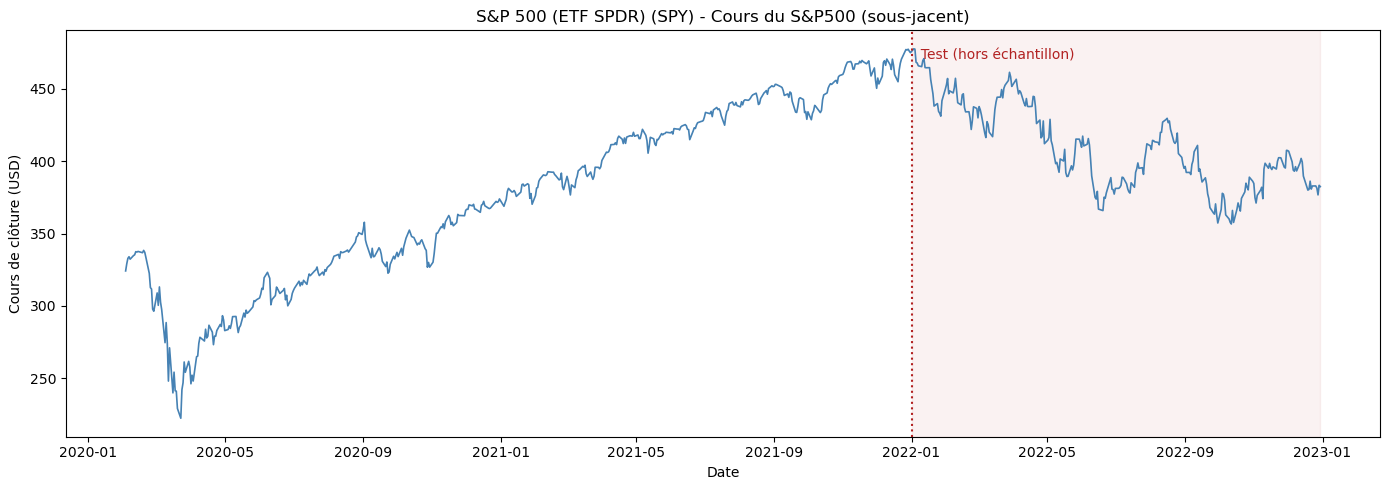

In [11]:
for tk in TICKERS:
    d = df_hist[tk]
    plt.figure(figsize=(14, 5))
    plt.plot(d['date'], d['close'], color='steelblue', linewidth=1.2)
    plt.axvline(pd.Timestamp(DATE_DEBUT_TEST), color='firebrick', linestyle=':', linewidth=1.5)
    plt.axvspan(pd.Timestamp(DATE_DEBUT_TEST), d['date'].max(), color='firebrick', alpha=0.06)
    plt.text(pd.Timestamp(DATE_DEBUT_TEST), d['close'].max(), '  Test (hors échantillon)',
             color='firebrick', va='top')
    plt.xlabel('Date'); plt.ylabel('Cours de clôture (USD)')
    plt.title(f'{NOMS_INDICE.get(tk, tk)} ({tk}) - Cours du S&P500 (sous-jacent)')
    plt.tight_layout(); plt.show(); plt.close()


**Volatilité réalisée et taux sans risque.** 
La volatilité réalisée (à gauche) varie fortement dans le temps, ce qui par ailleurs contredit déjà l'hypothèse (forte) de volatilité constante de Black-Scholes. 
Le taux (à droite) montre la hausse marquée de 2022, absente de la période d'entraînement : le réseau devra donc, sur le test, fonctionner dans un régime de taux qu'il n'a jamais rencontré.

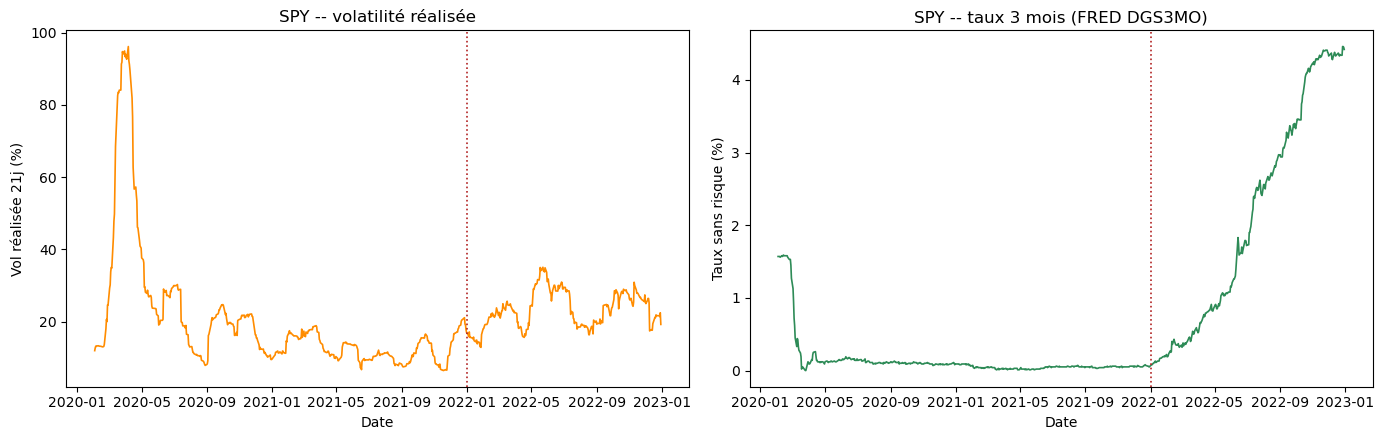

In [12]:
for tk in TICKERS:
    d = df_hist[tk]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(d['date'], d['vol_hist'] * 100, color='darkorange', linewidth=1.2)
    axes[0].axvline(pd.Timestamp(DATE_DEBUT_TEST), color='firebrick', linestyle=':', linewidth=1.2)
    axes[0].set_xlabel('Date'); axes[0].set_ylabel('Vol réalisée 21j (%)')
    axes[0].set_title(f'{tk} -- volatilité réalisée')

    axes[1].plot(d['date'], d['r'] * 100, color='seagreen', linewidth=1.2)
    axes[1].axvline(pd.Timestamp(DATE_DEBUT_TEST), color='firebrick', linestyle=':', linewidth=1.2)
    axes[1].set_xlabel('Date'); axes[1].set_ylabel('Taux sans risque (%)')
    axes[1].set_title(f'{tk} -- taux 3 mois (FRED DGS3MO)')
    plt.tight_layout(); plt.show(); plt.close()

La hausse des taux à partir de 2022 fait du test un horizon réellement nouveau pour le réseau
et non un simple découpage aléatoire.


**Distribution des prix d'options.** Nous comparons la distribution des prix entre le train et le test. Les deux périodes couvrent des gammes de prix comparables, ce qui est rassurant : le réseau ne sera pas évalué uniquement sur des prix qu'il n'a jamais vus à l'entraînement.

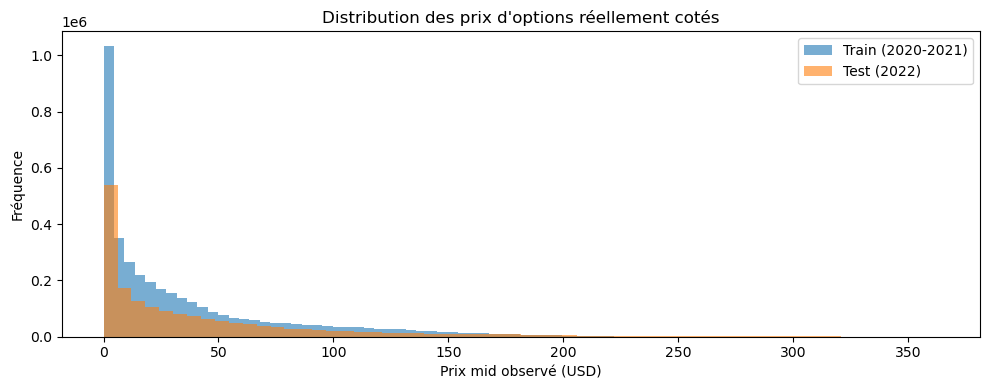

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(df_train['prix_mid'], bins=60, alpha=0.6, label='Train (2020-2021)')
plt.hist(df_test['prix_mid'],  bins=60, alpha=0.6, label='Test (2022)')
plt.xlabel('Prix mid observé (USD)'); plt.ylabel('Fréquence')
plt.title("Distribution des prix d'options réellement cotés")
plt.legend(); plt.tight_layout(); plt.show(); plt.close()


**Structure des prix en fonction du moneyness.** En normalisant le prix par le cours du sous-jacent, on retrouve la forme caractéristique attendue : un call vaut d'autant plus cher que le sous-jacent dépasse le strike (moneyness élevé), et symétriquement pour un put. C'est un contrôle de cohérence des données.

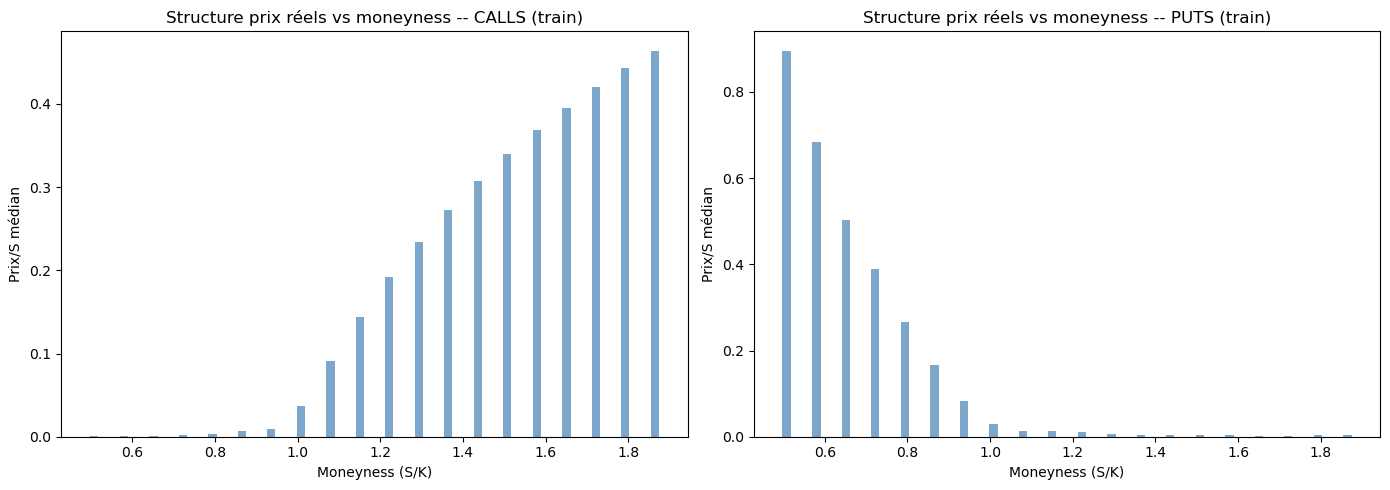

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, typ in zip(axes, ['call', 'put']):
    sous = df_train[df_train['type_option'] == typ].copy()
    if sous.empty:
        ax.set_title(f'Structure prix réels -- {typ.upper()}S (aucune donnée)'); continue
    sous['prix_norm'] = sous['prix_mid'] / sous['S']
    sous['mn_bin'] = pd.cut(sous['moneyness'], bins=20)
    stats = sous.groupby('mn_bin', observed=True)['prix_norm'].median()
    centres = [b.mid for b in stats.index]
    ax.bar(centres, stats.values, width=0.02, alpha=0.7, color='steelblue')
    ax.set_xlabel('Moneyness (S/K)'); ax.set_ylabel('Prix/S médian')
    ax.set_title(f'Structure prix réels vs moneyness -- {typ.upper()}S (train)')
plt.tight_layout(); plt.show(); plt.close()


Les données fournies sont cohérentes : on y voit bien une relation de symétrie entre les puts et les calls en fonction de la moneyness, ce qui est logique. 

Pour un call (option d'achat d'un sous-adjacent), plus son prix d'exercice est inférieur au prix actuel (spot), et plus l'option a de valeur, et l'inverse pour un put (option de vente).

C'est bien ce que l'on observe là, donc c'est cohérent avec la théorie financière, et le bon-sens (tout simplement !)

**Le smile de volatilité implicite.** 
C'est la visualisation la plus importante de cette partie. En traçant la volatilité implicite observée en fonction du moneyness, on constate qu'elle n'est **pas plate** : elle est plus élevée hors de la monnaie et dépend de la maturité. Cette courbe, communément appelée le « smile », est précisément ce que Black-Scholes, avec sa volatilité unique, ne peut pas reproduire. C'est la structure que notre pricer MLP devra apprendre à capturer à partir des seuls prix (ce que nous testerons en Partie IX).

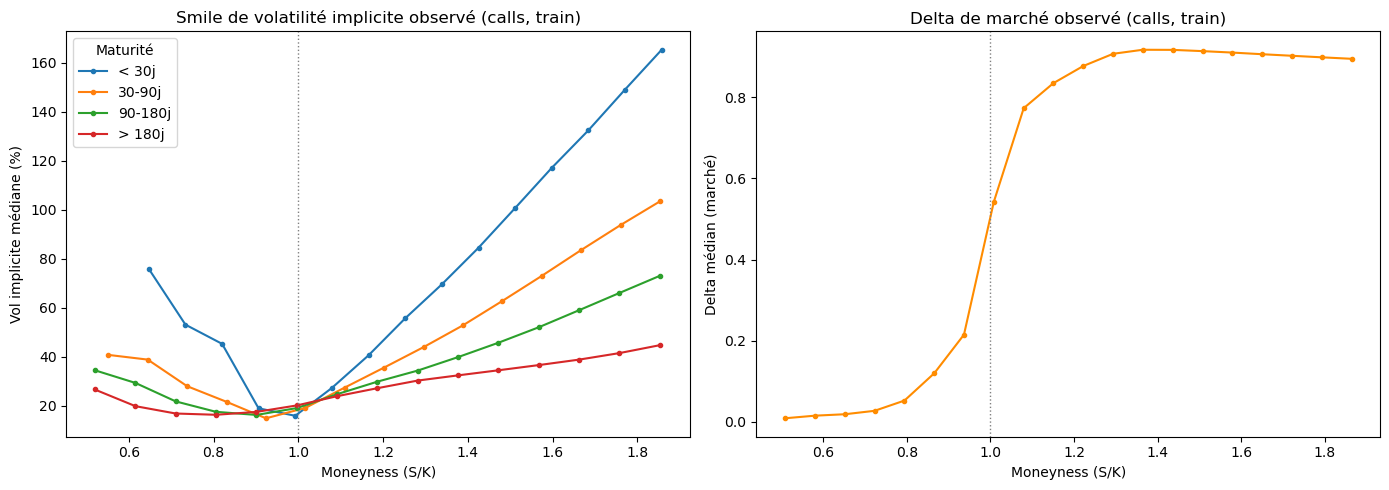

In [15]:
calls_train = df_train[(df_train['type_option'] == 'call') & df_train['iv_marche'].notna()].copy()
calls_train['dte_jours'] = (calls_train['T'] * 365).round()

BUCKETS_MATURITE = [(0, 30, '< 30j'), (30, 90, '30-90j'), (90, 180, '90-180j'), (180, 730, '> 180j')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Smile : vol implicite médiane par moneyness, pour différentes tranches de maturité.
for bas, haut, label in BUCKETS_MATURITE:
    sous = calls_train[calls_train['dte_jours'].between(bas, haut)]
    if len(sous) < 20:
        continue
    sous = sous.copy()
    sous['mn_bin'] = pd.cut(sous['moneyness'], bins=15)
    iv_med = sous.groupby('mn_bin', observed=True)['iv_marche'].median()
    centres = [b.mid for b in iv_med.index]
    axes[0].plot(centres, iv_med.values * 100, marker='o', markersize=3, label=label)
axes[0].axvline(1.0, color='grey', linestyle=':', linewidth=1)
axes[0].set_xlabel('Moneyness (S/K)'); axes[0].set_ylabel('Vol implicite médiane (%)')
axes[0].set_title('Smile de volatilité implicite observé (calls, train)')
axes[0].legend(title='Maturité')

# Delta de marché par moneyness (contrôle de cohérence).
calls_train['mn_bin'] = pd.cut(calls_train['moneyness'], bins=20)
delta_med = calls_train.groupby('mn_bin', observed=True)['delta_marche'].median()
centres = [b.mid for b in delta_med.index]
axes[1].plot(centres, delta_med.values, marker='o', markersize=3, color='darkorange')
axes[1].axvline(1.0, color='grey', linestyle=':', linewidth=1)
axes[1].set_xlabel('Moneyness (S/K)'); axes[1].set_ylabel('Delta médian (marché)')
axes[1].set_title('Delta de marché observé (calls, train)')

plt.tight_layout(); plt.show(); plt.close()


Le smile n'est pas plat : c'est exactement ce que Black-Scholes ne peut pas capturer et ce que le pricer MLP devra apprendre à partir des seuls prix (Partie IX). 

# Partie IV - Normalisation et préparation des tenseurs

**Maintenant, avant de commencer l'entraînement, on doit traiter nos données :** 

- En effet, les variables d'entrée ont des échelles très différentes (un strike se compte en centaines de dollars, une volatilité vaut quelques dixièmes). Sans mise à l'échelle, le réseau accorderait mécaniquement plus de poids aux variables aux grandes valeurs.
- Nous appliquons donc une **normalisation min-max** qui ramène chaque variable dans l'intervalle [0, 1].
- Egalement, nous avons fait en sorte que les bornes de normalisation sont calculées **uniquement sur les données d'entraînement**. Les calculer sur l'ensemble (train + test) reviendrait à laisser fuiter de l'information sur le futur (2022) vers la phase d'apprentissage, ce qui fausserait l'évaluation.

Avant l'entraînement, nous appliquons aussi le **plafond sur le nombre de lignes** défini en Partie I. Si le jeu d'entraînement dépasse `MAX_LIGNES_TRAIN`, nous en tirons un échantillon aléatoire : un MLP de cette taille n'a pas besoin de plusieurs millions de contrats pour converger, et surtout, permet l'entraînement sur mon potato PC

In [16]:
# Sous-échantillonnage éventuel du train, pour rester confortable en mémoire et en temps de calcul.

if MAX_LIGNES_TRAIN is not None and len(df_train) > MAX_LIGNES_TRAIN:
    df_train = df_train.sample(n=MAX_LIGNES_TRAIN, random_state=GRAINE).reset_index(drop=True)
    print(f'Train sous-échantillonné à {len(df_train):,} contrats (plafond MAX_LIGNES_TRAIN).')
else:
    print(f'Train conservé intégralement : {len(df_train):,} contrats.')


Train sous-échantillonné à 400,000 contrats (plafond MAX_LIGNES_TRAIN).


In [17]:
# Construction des matrices X (variables d'entrée) et y (prix à prédire), séparément train/test.

X_train_brut = df_train[VARIABLES].values.astype(np.float32)
y_train_brut = df_train['prix_mid'].values.astype(np.float32).reshape(-1, 1)
X_test_brut = df_test[VARIABLES].values.astype(np.float32)
y_test_brut = df_test['prix_mid'].values.astype(np.float32).reshape(-1, 1)

# Bornes de normalisation : calculées sur le TRAIN uniquement (pas de fuite du futur).
BORNES = {nom: (X_train_brut[:, i].min(), X_train_brut[:, i].max())
          for i, nom in enumerate(VARIABLES)}
print('Bornes de normalisation (train) :')
for nom, (b, h) in BORNES.items():
    print(f'  {nom:<8}: [{b:.4f}, {h:.4f}]')


Bornes de normalisation (train) :
  S       : [222.2100, 477.4800]
  K       : [120.0000, 720.0000]
  T       : [0.0083, 2.0000]
  sqrt_T  : [0.0913, 1.4142]
  sigma   : [0.0650, 0.9616]
  r       : [0.0000, 0.0159]
  type_num: [0.0000, 1.0000]


Nous définissons une fonction de normalisation réutilisable (elle resservira en Partie VIII pour les Greeks), puis nous découpons le train en un sous-ensemble d'apprentissage et un sous-ensemble de validation. Nous mesurons enfin la part du test qui « extrapole » hors du domaine vu à l'entraînement : c'est un indicateur essentiel pour interpréter les erreurs en Partie X, car aucun modèle appris ne peut être fiable là où il n'a jamais vu de données.

In [18]:
def normaliser(X):
    """Normalisation min-max, avec garde contre une plage nulle (variable constante)."""
    X_n = np.zeros_like(X, dtype=np.float32)
    for i, nom in enumerate(VARIABLES):
        b, h = BORNES[nom]
        e = h - b
        X_n[:, i] = (X[:, i] - b) / e if e > 0 else 0.0
    return X_n

X_tr_full = normaliser(X_train_brut)
X_te      = normaliser(X_test_brut)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr_full, y_train_brut, test_size=TAILLE_VAL, random_state=GRAINE
)
print(f'Apprentissage : {X_tr.shape[0]:,} | Validation : {X_val.shape[0]:,} | Test : {X_te.shape[0]:,}')

# Part du test hors du domaine d'entraînement (servira à interpréter les écarts en Partie X).
hors_bornes = np.zeros(X_test_brut.shape[0], dtype=bool)
for i, nom in enumerate(VARIABLES):
    b, h = BORNES[nom]
    hors_bornes |= (X_test_brut[:, i] < b) | (X_test_brut[:, i] > h)
print(f"Part du test extrapolant hors du domaine vu à l'entraînement : {hors_bornes.mean()*100:.1f}%")


Apprentissage : 340,000 | Validation : 60,000 | Test : 1,799,097
Part du test extrapolant hors du domaine vu à l'entraînement : 53.2%


# Partie V - Entraînement du pricer MLP


Maintenant que toutes les phrases préliminaires ont été réalisés, nous passons à l'entraînement de notre modèle.

Pour cela, nous avons décidé de nous rattacher à ce que nous connaissons : nous avons choisi de construire un perceptron multicouche sur le même principe que celui du TP5, mais adapté à une tâche de **régression** : la couche de sortie est linéaire (sans activation), car un prix d'option n'est pas une probabilité et n'est donc pas borné dans [0, 1].

Chaque couche cachée est suivie d'une `BatchNormalization`, qui stabilise l'entraînement, qui nous est indispensable ici car les prix réels sont plus bruités que des prix recalculés par une formule. 

Enfin, nous appelons `clear_session()` avant de construire le modèle : sans cela, Keras accumulerait en mémoire les références aux modèles précédents à chaque réexécution de la cellule, et la RAM grossirait inutilement (j'ai dépassé les 40Go de RAM utilisés, en comptant la RAM dynamique... saturant à la fois ma ram et mon SSD).

In [19]:
def creer_mlp(dim, nb_couches=NB_COUCHES, nb_neurones=NEURONES):
    """MLP de régression : couches Dense (activation tanh) + BatchNorm, sortie linéaire."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(GRAINE)
    inp = tf.keras.Input(shape=(dim,))
    x = inp
    for _ in range(nb_couches):
        x = Dense(nb_neurones, activation=ACTIVATION)(x)
        x = BatchNormalization()(x)
    out = Dense(1, activation=None)(x)   # sortie linéaire : un prix n'est pas borné
    m = tf.keras.Model(inp, out)
    m.compile(optimizer=Adam(LR), loss=MeanSquaredError(), metrics=['mae'])
    return m

pricer = creer_mlp(dim=len(VARIABLES))
pricer.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 7)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 96)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 96)                  │           9,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 96)                  │           9,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 96)                  │           9,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 96)                  │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              97 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,337 (118.50 KB)

 Trainable params: 29,569 (115.50 KB)

 Non-trainable params: 768 (3.00 KB)

**Egalement, nous entraînons le réseau avec deux garde-fous automatiques.**

- `EarlyStopping` interrompt l'apprentissage dès que la performance de validation cesse de progresser (et restaure les meilleurs poids), ce qui évite à la fois le surapprentissage et le temps perdu sur des epochs inutiles.
- `ReduceLROnPlateau` diminue le taux d'apprentissage lorsque la validation stagne, pour affiner la convergence en fin d'entraînement.
- Enfin, nous laissons `verbose=0` car, lors de nos essais précédents, affciher la progression dans le notebook saturait la mémoire et faisait buguer le tout. Nous serons avertis à la fin de l'entraînement par le message dans print.

In [20]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
]

historique = pricer.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=NB_EPOCHS,
    batch_size=TAILLE_BATCH,
    callbacks=callbacks,
    verbose=0, # silencieux : évite la saturation de l'affichage (cf. markdown ci-dessus)
)
print(f"Entraînement terminé à l'epoch {len(historique.history['loss'])} / {NB_EPOCHS}.")


Entraînement terminé à l'epoch 26 / 60.


Nous traçons les courbes d'apprentissage. Si les courbes d'entraînement et de validation restent proches et décroissent régulièrement, l'apprentissage est sain et il n'y a pas de surapprentissage trop marqué.

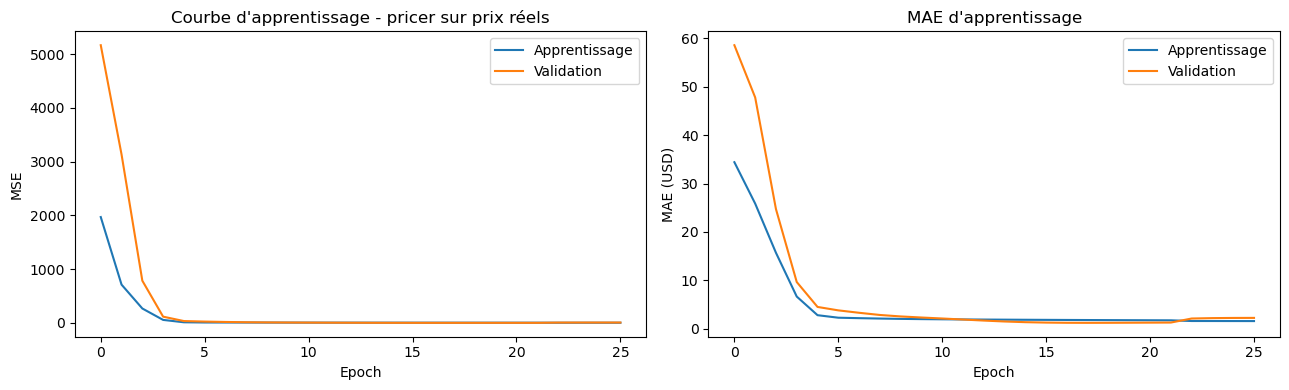

MSE validation finale : 8.6241
MAE validation finale : 2.2128 USD


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(historique.history['loss'],     label='Apprentissage')
axes[0].plot(historique.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title("Courbe d'apprentissage - pricer sur prix réels"); axes[0].legend()

axes[1].plot(historique.history['mae'],     label='Apprentissage')
axes[1].plot(historique.history['val_mae'], label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (USD)')
axes[1].set_title("MAE d'apprentissage"); axes[1].legend()
plt.tight_layout(); plt.show(); plt.close()

print(f'MSE validation finale : {historique.history["val_loss"][-1]:.4f}')
print(f'MAE validation finale : {historique.history["val_mae"][-1]:.4f} USD')


# Partie VI - Pricing Black-Scholes sur le jeu de test


Pour comparer le réseau à Black-Scholes, nous implémentons d'abord la formule (prix et Greeks). Nous calculerons ensuite deux versions de Black-Scholes sur le test, qui répondent à deux questions différentes :

- **BS (σ_hist)** reçoit exactement la même information que le réseau (la volatilité réalisée du sous-jacent). C'est la comparaison à armes égales avec notre modèle, et qui nous permet de voir : à information identique, qui price le mieux ?
- **BS oracle (σ_IV marché)** : reçoit la vraie volatilité implicite de chaque contrat, une donnée exploitée dans la vraie vie par les traders mais qui ne le sera pas dans notre réseau (on déduit la volatilité implicite grâce aux prix des options sur le marché A L'AIDE de Black-Scholes : ça serait tautologique de donner cette information à notre modèle... Ce n'est donc pas un concurrent loyal, mais un outil de diagnostic : il nous permet d'isoler la part d'erreur qui est inévitable avec Black-Scholes, peu importe la volatilité qu'on lui donne, car elle vient de ses hypothèses simplificatrices (modèle européen, sans dividendes…). Autrement dit, si notre réseau fait moins d'erreur que BS oracle, c'est qu'il apprend quelque chose que Black-Scholes ne pourra jamais capturer, même dans ses meilleures conditions.

In [22]:
# On calcule D1 et D2, qui sont des "quantités intermédiaires" que l'on calcule par convention 
# pour utiliser Black-Scholes (vous aurez l'occasion de voir cela lors de notre présentation).

def calculer_d1_d2(S, K, T, sigma, r):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

# On calcule le prix d'un call européen via la formule de Black Scholes

def bs_call(S, K, T, sigma, r):
    d1, d2 = calculer_d1_d2(S, K, T, sigma, r)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# On procède de même sur le prix des puts (que l'on déduit par la parité call-put)

def bs_put(S, K, T, sigma, r):
    return bs_call(S, K, T, sigma, r) - S + K * np.exp(-r * T)

# Puis on défini une fonction qui nous retourne directement le prix de l'option selon son type (call ou put)

def bs_price(S, K, T, sigma, r, type_option):
    return np.where(np.asarray(type_option) == 'call',
                    bs_call(S, K, T, sigma, r),
                    bs_put(S, K, T, sigma, r))

# Et pour terminer, on défini une fonction qui calcule les fameux greeks de ces dits options.

def greeks_bs_call(S, K, T, sigma, r):
    d1, d2 = calculer_d1_d2(S, K, T, sigma, r)
    phi = norm.pdf(d1)
    return {
        'delta': norm.cdf(d1),
        'gamma': phi / (S * sigma * np.sqrt(T)),
        'vega':  S * phi * np.sqrt(T),
    }

# Et la cerise sur le gâteau, un petit print de débugage.

print('Formules Black-Scholes définies.')


Formules Black-Scholes définies.


Nous appliquons maintenant ces formules au jeu de test, et nous y ajoutons la prédiction du réseau. Nous obtenons ainsi, pour chaque contrat de 2022, quatre valeurs côte à côte : le prix de marché observé, le prix BS (σ_hist), le prix BS oracle (σ_IV) et le prix MLP.

In [23]:
# BS avec sigma_hist : comparaison avec le MLP (même information).

df_test['prix_bs_hist'] = bs_price(
    df_test['S'].values, df_test['K'].values, df_test['T'].values,
    df_test['sigma'].values, df_test['r'].values, df_test['type_option'].values,
)

# BS oracle avec sigma_IV de marché : borne indicative

masque_iv = df_test['iv_marche'].notna() & (df_test['iv_marche'] > 0)
df_test['prix_bs_oracle'] = np.nan
df_test.loc[masque_iv, 'prix_bs_oracle'] = bs_price(
    df_test.loc[masque_iv, 'S'].values, df_test.loc[masque_iv, 'K'].values,
    df_test.loc[masque_iv, 'T'].values, df_test.loc[masque_iv, 'iv_marche'].values,
    df_test.loc[masque_iv, 'r'].values, df_test.loc[masque_iv, 'type_option'].values,
)

# Prédiction du pricer MLP (prix borné à 0 car prix d'option ne peut pas être négatif)

df_test['prix_mlp'] = pricer.predict(X_te, verbose=0).flatten().clip(min=0)

print(f'Contrats test avec sigma_IV disponible : {masque_iv.sum():,} / {len(df_test):,}')
df_test[['ticker', 'type_option', 'K', 'T', 'S', 'sigma',
         'prix_mid', 'prix_bs_hist', 'prix_bs_oracle', 'prix_mlp']].head(10)


Contrats test avec sigma_IV disponible : 1,691,980 / 1,799,097


,ticker,type_option,K,T,S,sigma,prix_mid,prix_bs_hist,prix_bs_oracle,prix_mlp
0,SPY,put,439.0,0.451945,477.77,0.163495,12.765,6.334503,12.495539,15.084042
1,SPY,put,443.0,0.451945,477.77,0.163495,13.545,7.331216,13.222407,15.984175
2,SPY,put,442.0,0.451945,477.77,0.163495,13.345,7.072187,13.093664,15.755021
3,SPY,put,441.0,0.451945,477.77,0.163495,13.130,6.819776,12.900181,15.528628
4,SPY,put,440.0,0.451945,477.77,0.163495,12.940,6.573907,12.623394,15.304976
5,SPY,put,435.0,0.451945,477.77,0.163495,12.035,5.439918,11.816605,14.227480
6,SPY,put,437.0,0.451945,477.77,0.163495,12.375,5.874770,12.072166,14.650330
7,SPY,put,436.0,0.451945,477.77,0.163495,12.250,5.654277,12.047124,14.437548
8,SPY,put,444.0,0.451945,477.77,0.163495,13.730,7.596937,13.457871,16.216091
9,SPY,put,434.0,0.451945,477.77,0.163495,11.835,5.231609,11.593898,14.020111


Une petite représentation des différentes valeurs associées à plusieurs puts. 

# Partie VII - Comparaison tripartite : MLP · Black-Scholes · prix de marché

Nous mesurons maintenant, sur l'année de test 2022, l'écart de chaque modèle au prix de marché réellement observé. Nous utilisons quatre métriques complémentaires : 
- la **MAE** (erreur absolue moyenne, en dollars),
- la **RMSE** (qui pénalise davantage les grosses erreurs),
- le **MAPE** (erreur relative en %, parlant mais instable sur les options bon marché) et
- le **R²** (part de variance expliquée).

In [24]:
# On calcule MAE, RMSE, MAPE et R2 et on les affiche sur une ligne

def metriques(y_reel, y_pred, label):
    mae = mean_absolute_error(y_reel, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reel, y_pred))
    mape = (np.abs(y_pred - y_reel) / y_reel).mean() * 100
    r2 = 1 - np.sum((y_reel - y_pred) ** 2) / np.sum((y_reel - y_reel.mean()) ** 2)
    print(f'{label:<28}  MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%  R2={r2:.4f}')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


Nous calculons d'abord les métriques globales sur l'ensemble du test, pour les trois modèles.

In [25]:
y_reel = df_test['prix_mid'].values
sous_oracle = df_test[masque_iv]

print(f'Jeu de test : {len(df_test):,} // options ({DATE_DEBUT_TEST} -> {DATE_FIN_TEST})')
res = []
res.append(metriques(y_reel, df_test['prix_bs_hist'].values, 'Black-Scholes (sigma_hist)'))
res.append(metriques(y_reel, df_test['prix_mlp'].values, 'MLP (sigma_hist)'))
res.append(metriques(sous_oracle['prix_mid'].values, sous_oracle['prix_bs_oracle'].values, 'BS oracle (sigma_IV marché)'))
df_res = pd.DataFrame(res)


Jeu de test : 1,799,097 // options (2022-01-01 -> 2022-12-31)
Black-Scholes (sigma_hist)    MAE=2.6661  RMSE=4.5667  MAPE=66.6%  R2=0.9934
MLP (sigma_hist)              MAE=13.2658  RMSE=27.6092  MAPE=429.6%  R2=0.7596
BS oracle (sigma_IV marché)   MAE=0.7358  RMSE=1.6843  MAPE=4.9%  R2=0.9990


Puis nous détaillons les performances séparément pour les calls et les puts, car rien ne garantit *a priori* que le réseau price aussi bien les deux types de contrats.

In [26]:
for typ in ['call', 'put']:
    sous = df_test[df_test['type_option'] == typ]
    print(f'\n--- {typ.upper()}S ({len(sous):,}) ---')
    metriques(sous['prix_mid'].values, sous['prix_bs_hist'].values, 'BS (sigma_hist)')
    metriques(sous['prix_mid'].values, sous['prix_mlp'].values,     'MLP')



--- CALLS (846,489) ---
BS (sigma_hist)               MAE=2.3899  RMSE=3.9713  MAPE=109.0%  R2=0.9926
MLP                           MAE=8.7837  RMSE=13.3632  MAPE=419.6%  R2=0.9167

--- PUTS (952,608) ---
BS (sigma_hist)               MAE=2.9114  RMSE=5.0370  MAPE=29.0%  R2=0.9937
MLP                           MAE=17.2486  RMSE=35.7901  MAPE=438.5%  R2=0.6836


**Premier graphique : prix prédit contre prix de marché.** Plus les points sont alignés sur la diagonale, meilleur est le modèle. Cette vue d'ensemble révèle immédiatement les biais et la dispersion de chaque approche.

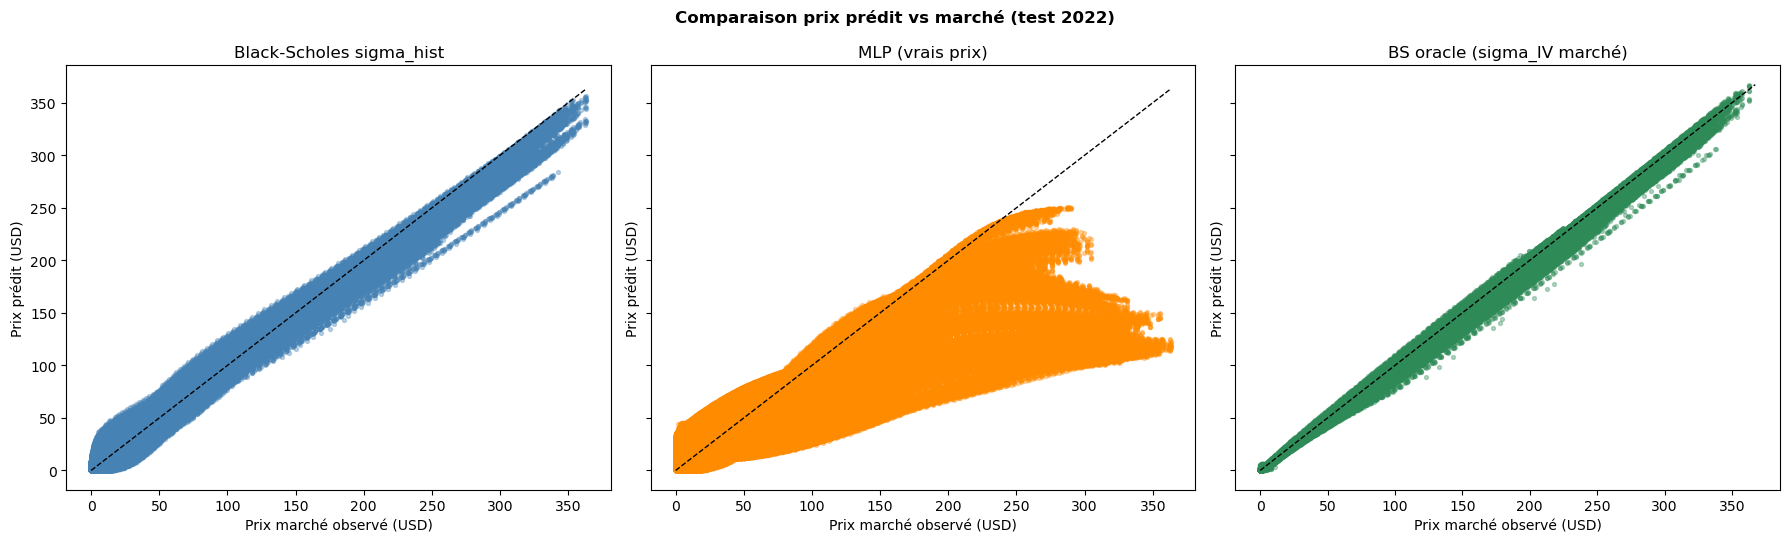

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, df_plot, col, titre, couleur in [
    (axes[0], df_test,     'prix_bs_hist',   'Black-Scholes sigma_hist',    'steelblue'),
    (axes[1], df_test,     'prix_mlp',       'MLP (vrais prix)',            'darkorange'),
    (axes[2], sous_oracle, 'prix_bs_oracle', 'BS oracle (sigma_IV marché)', 'seagreen'),
]:
    ax.scatter(df_plot['prix_mid'], df_plot[col], alpha=0.35, s=8, color=couleur)
    borne = max(df_plot['prix_mid'].max(), df_plot[col].max())
    ax.plot([0, borne], [0, borne], 'k--', linewidth=1)
    ax.set_xlabel('Prix marché observé (USD)'); ax.set_ylabel('Prix prédit (USD)')
    ax.set_title(titre)
plt.suptitle('Comparaison prix prédit vs marché (test 2022)', fontweight='bold')
plt.tight_layout(); plt.show(); plt.close()


Ici, on voit notre modèle est globalement moins bon que celui de Black-Scholes (surtout BS_oracle, qui est le pricing qu'obtiendrait un vrai trader, qui utiliserait à la fois BS et la volatilité implicite)... Néanmoins, on note qu'il y quand même une certaine cohérence dans les prix qu'ils nous proposent (on y voit une corrélation relative avec les prix réels)

**Deuxième graphique : erreur relative en fonction du moneyness (calls).** Il localise *où* chaque modèle se trompe. On s'attend à ce que Black-Scholes (σ_hist) dévie surtout là où le smile est marqué, et à ce que l'erreur relative explose autour de la monnaie pour les options bon marché (un petit écart en dollars y devient un grand écart en pourcentage).

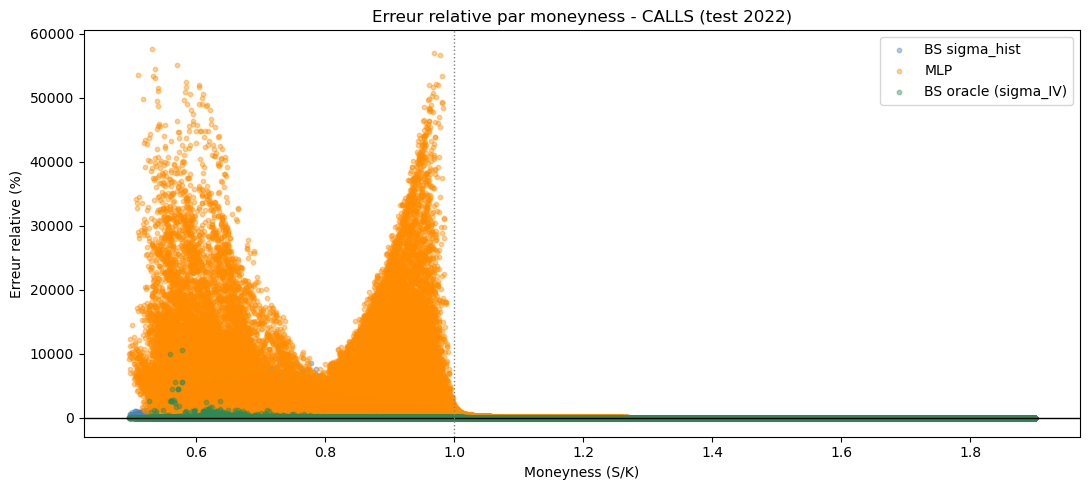

In [28]:
df_calls_test = df_test[df_test['type_option'] == 'call'].copy()

fig, ax = plt.subplots(figsize=(11, 5))
for col, couleur, label, df_plot in [
    ('prix_bs_hist',   'steelblue',  'BS sigma_hist',        df_calls_test),
    ('prix_mlp',       'darkorange', 'MLP',                  df_calls_test),
    ('prix_bs_oracle', 'seagreen',   'BS oracle (sigma_IV)', df_calls_test[df_calls_test['prix_bs_oracle'].notna()]),
]:
    err_rel = (df_plot[col] - df_plot['prix_mid']) / df_plot['prix_mid'] * 100
    ax.scatter(df_plot['moneyness'], err_rel, alpha=0.4, s=10, color=couleur, label=label)
ax.axhline(0, color='k', linewidth=1)
ax.axvline(1.0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Moneyness (S/K)'); ax.set_ylabel('Erreur relative (%)')
ax.set_title('Erreur relative par moneyness - CALLS (test 2022)')
ax.legend(); plt.tight_layout(); plt.show(); plt.close()


On voit d'importants erreurs sur notre modèle d'apprentissage pour les produits avec une moneyness inférieur à 1 (dans le jargon financier, on dit que le call est out of the money dans ce cas). 

**Troisième graphique : erreur absolue par maturité.** Les boîtes à moustaches montrent comment l'erreur de chaque modèle évolue avec le temps restant jusqu'à l'échéance. C'est notamment ici que l'ajout de la variable `sqrt_T` est censé aider le réseau sur les courtes maturités.

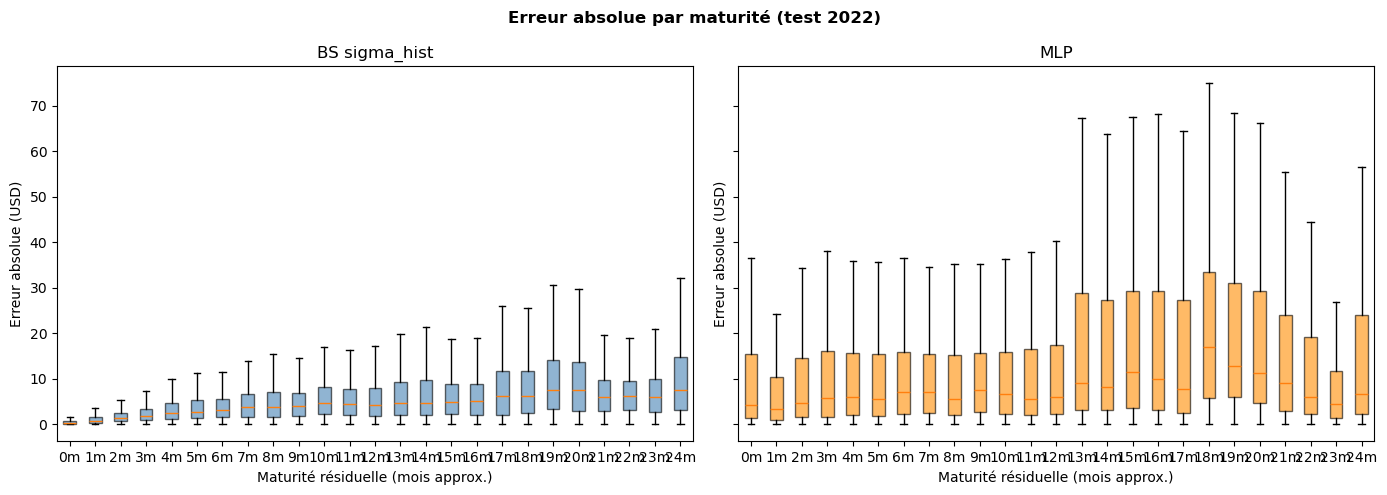

In [29]:
df_test['T_mois'] = (df_test['T'] * 12).round().astype(int)
maturites_uniq = sorted(df_test['T_mois'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, col, titre, couleur in [
    (axes[0], 'prix_bs_hist', 'BS sigma_hist', 'steelblue'),
    (axes[1], 'prix_mlp',     'MLP',           'darkorange'),
]:
    donnees = [np.abs(df_test[df_test['T_mois'] == m][col] -
                      df_test[df_test['T_mois'] == m]['prix_mid']).values
               for m in maturites_uniq]
    bp = ax.boxplot(donnees, labels=[f'{m}m' for m in maturites_uniq], patch_artist=True, showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(couleur); patch.set_alpha(0.6)
    ax.set_xlabel('Maturité résiduelle (mois approx.)'); ax.set_ylabel('Erreur absolue (USD)')
    ax.set_title(titre)
plt.suptitle('Erreur absolue par maturité (test 2022)', fontweight='bold')
plt.tight_layout(); plt.show(); plt.close()


# Partie VIII - Extraction des Greeks par différentiation automatique


Nous passons maintenant à la partie la plus technique notre projet : l'extraction des greeks. 
Nous avons décidé d'utiliser ce qui a été vu lors du TP2, la descente de gradient, pour entraîner notre réseau. 
Une fois entraîné, le réseau est une fonction différentiable du prix par rapport à ses entrées. Nous pouvons donc obtenir les Greeks non pas par leurs formules analytiques, mais en différentiant automatiquement le réseau avec `tf.GradientTape` :

- le **Delta** (sensibilité au sous-jacent) est la dérivée première du prix par rapport à `S` : un seul `GradientTape`, comme la descente de gradient du TP2 ;
- le **Gamma** est la dérivée seconde par rapport à `S` : deux `GradientTape` imbriqués, exactement la construction de la Hessienne du TP2, appliquée cette fois à un réseau plutôt qu'à une fonction analytique ;
- le **Vega** est la dérivée par rapport à `σ`.

Nons avons également procédé d'une astuce d'implémentation importante : nous plaçons `S` (en valeur réelle) sous surveillance du tape, puis nous effectuons la normalisation à l'intérieur du tape. Le gradient renvoyé est ainsi déjà exprimé dans l'échelle réelle (en dollars par dollar de sous-jacent), sans aucun retraitement manuel.

In [30]:
# Construit le tenseur d'entrée normalisé à partir des variables RÉELLES.
# La normalisation est faite ici (dans le tape) pour que le gradient sorte à l'échelle réelle.

def construire_input_nn(S, K, T, sqrt_T, sigma, r, type_num):
    vals = [S, K, T, sqrt_T, sigma, r, type_num]
    cols = []
    for v, nom in zip(vals, VARIABLES):
        b, h = BORNES[nom]
        e = h - b
        col = (v - b) / e if e > 0 else tf.zeros_like(v)
        cols.append(col)
    return tf.stack(cols, axis=1)

# Prépare les entrées constantes communes aux trois Greeks (sqrt_T est cohérent avec T).

def _constantes(S, K, T, sigma, r, type_num):
    return {
        'K':       tf.constant(K, tf.float32),
        'T':       tf.constant(T, tf.float32),
        'sqrt_T':  tf.constant(np.sqrt(T), tf.float32),
        'sigma':   tf.constant(sigma, tf.float32),
        'r':       tf.constant(r, tf.float32),
        'type_num':tf.constant(np.full_like(S, type_num), tf.float32),
    }


In [31]:
# Delta = d(prix)/dS, par un seul GradientTape (dérivée première)

def delta_nn(modele, S, K, T, sigma, r, type_num=0.0):
    c = _constantes(S, K, T, sigma, r, type_num)
    S_v = tf.Variable(S, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(S_v)
        p = modele(construire_input_nn(S_v, c['K'], c['T'], c['sqrt_T'], c['sigma'], c['r'], c['type_num']))
    return tape.gradient(p, S_v).numpy().flatten()

# Gamma = d2(prix)/dS2, par deux GradientTape imbriqués (comme la Hessienne du TP2).

def gamma_nn(modele, S, K, T, sigma, r, type_num=0.0):
    c = _constantes(S, K, T, sigma, r, type_num)
    S_v = tf.Variable(S, dtype=tf.float32)
    with tf.GradientTape() as t2:
        t2.watch(S_v)
        with tf.GradientTape() as t1:
            t1.watch(S_v)
            p = modele(construire_input_nn(S_v, c['K'], c['T'], c['sqrt_T'], c['sigma'], c['r'], c['type_num']))
        g = t1.gradient(p, S_v)
    return t2.gradient(g, S_v).numpy().flatten()

# Vega = d(prix)/d(sigma), par un seul GradientTape.

def vega_nn(modele, S, K, T, sigma, r, type_num=0.0):
    c = _constantes(S, K, T, sigma, r, type_num)
    sig_v = tf.Variable(sigma, dtype=tf.float32)
    S_c = tf.constant(S, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(sig_v)
        p = modele(construire_input_nn(S_c, c['K'], c['T'], c['sqrt_T'], sig_v, c['r'], c['type_num']))
    return tape.gradient(p, sig_v).numpy().flatten()

print('Fonctions Greeks_NN définies.')


Fonctions Greeks_NN définies.


Nous comparons d'abord les Greeks du réseau à ceux de Black-Scholes, en moyenne, sur tous les calls du test. C'est un premier contrôle quantitatif : un Delta moyen proche entre les deux méthodes est bon signe ; un Gamma dont l'erreur dépasse la valeur moyenne signale au contraire un signal noyé dans le bruit de la dérivée seconde.

In [32]:
df_c_test = df_test[df_test['type_option'] == 'call'].copy().reset_index(drop=True)
S_arr = df_c_test['S'].values.astype(np.float32)
K_arr = df_c_test['K'].values.astype(np.float32)
T_arr = df_c_test['T'].values.astype(np.float32)
sig_arr = df_c_test['sigma'].values.astype(np.float32)
r_arr = df_c_test['r'].values.astype(np.float32)

delta_N = delta_nn(pricer, S_arr, K_arr, T_arr, sig_arr, r_arr, type_num=0.0)
gamma_N = gamma_nn(pricer, S_arr, K_arr, T_arr, sig_arr, r_arr, type_num=0.0)
vega_N = vega_nn(pricer,  S_arr, K_arr, T_arr, sig_arr, r_arr, type_num=0.0)
g_bs = greeks_bs_call(S_arr, K_arr, T_arr, sig_arr, r_arr)

print('Comparaison Greeks_NN vs Greeks_BS (calls, test) :')
print(f'{"Greek":<8}{"NN moyen":>12}{"BS moyen":>12}{"MAE":>12}')
for nom, nn_val in [('delta', delta_N), ('gamma', gamma_N), ('vega', vega_N)]:
    bs_val = g_bs[nom]
    print(f'{nom:<8}{nn_val.mean():>12.5f}{bs_val.mean():>12.5f}{mean_absolute_error(bs_val, nn_val):>12.5f}')


Comparaison Greeks_NN vs Greeks_BS (calls, test) :
Greek       NN moyen    BS moyen         MAE
delta        0.46310     0.57664     0.16478
gamma        0.00348     0.00570     0.00390
vega         4.77167    47.79900    46.66931


Nous traçons ensuite les courbes de Delta et Gamma en fonction du moneyness, à conditions de marché médianes. Le Delta du réseau devrait suivre la courbe en S de Black-Scholes ; le Gamma, en tant que dérivée seconde, est structurellement plus difficile à restituer proprement : c'est un point que nous discuterons honnêtement au bilan.

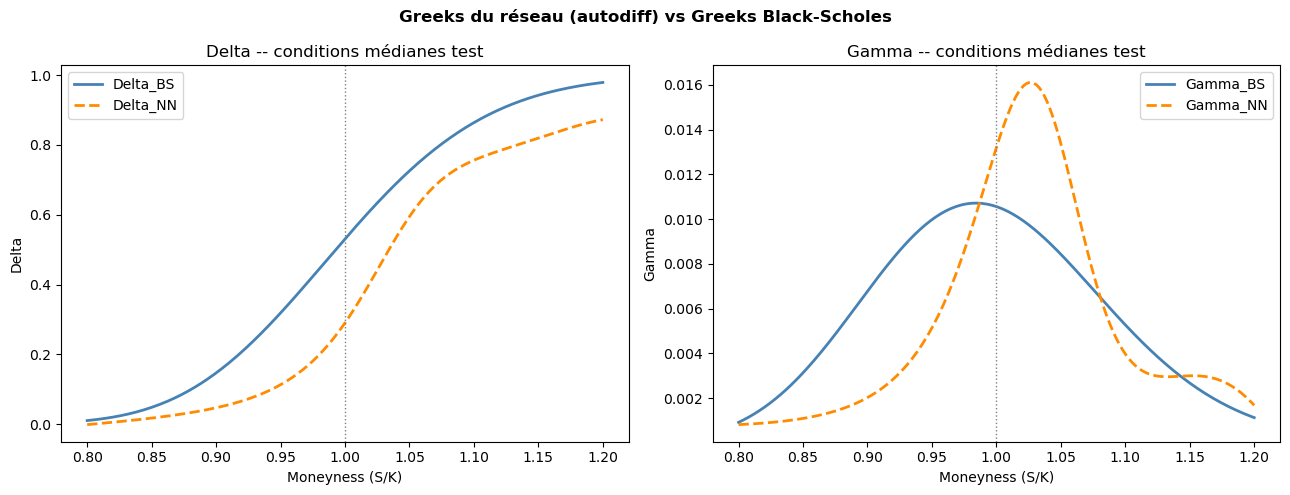

Un écart Delta_NN / Delta_BS sur les ailes indiquerait que le réseau a capté le skew du marché.


In [33]:
T_med = float(np.median(T_arr));   r_med   = float(np.median(r_arr))
sig_med = float(np.median(sig_arr));  K_med   = float(np.median(K_arr))

S_courbe = np.linspace(K_med * 0.80, K_med * 1.20, NB_POINTS_COURBE).astype(np.float32)
K_cst = np.full(NB_POINTS_COURBE, K_med,   dtype=np.float32)
T_cst = np.full(NB_POINTS_COURBE, T_med,   dtype=np.float32)
sig_cst = np.full(NB_POINTS_COURBE, sig_med, dtype=np.float32)
r_cst = np.full(NB_POINTS_COURBE, r_med,   dtype=np.float32)
mn_c = S_courbe / K_cst

d_nn = delta_nn(pricer, S_courbe, K_cst, T_cst, sig_cst, r_cst, 0.0)
gm_nn = gamma_nn(pricer, S_courbe, K_cst, T_cst, sig_cst, r_cst, 0.0)
g_bs_c = greeks_bs_call(S_courbe, K_cst, T_cst, sig_cst, r_cst)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, nom, nn_val in [(axes[0], 'delta', d_nn), (axes[1], 'gamma', gm_nn)]:
    ax.plot(mn_c, g_bs_c[nom], label=f'{nom.capitalize()}_BS', linewidth=2, color='steelblue')
    ax.plot(mn_c, nn_val, '--', label=f'{nom.capitalize()}_NN', linewidth=2, color='darkorange')
    ax.axvline(1.0, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('Moneyness (S/K)'); ax.set_ylabel(nom.capitalize())
    ax.set_title(f'{nom.capitalize()} -- conditions médianes test'); ax.legend()
plt.suptitle('Greeks du réseau (autodiff) vs Greeks Black-Scholes', fontweight='bold')
plt.tight_layout(); plt.show(); plt.close()

print('Un écart Delta_NN / Delta_BS sur les ailes indiquerait que le réseau a capté le skew du marché.')


Ici, on voit que le delta et le gamma estimé par notre modèle diffère largement des résultats théoriques. Ca signifie que soit le réseau a capté le skew du marché, ou que soit le réseau nous produit des résultats pas super bons... 

# Partie IX - Le pricer a-t-il appris le smile de volatilité ?

Voici le test le plus direct de la promesse du projet. Pour chaque contrat d'une journée de test, nous inversons Black-Scholes (par la méthode de Brent) afin de trouver la volatilité qui ferait coller `BS(σ)` au **prix prédit par le MLP**. Si ce « σ implicite du MLP » reproduit la forme du smile réellement observé sur le marché (Partie III), alors que le réseau n'a jamais reçu la volatilité implicite en entrée, c'est la preuve qu'il a appris la structure du smile à partir des seuls prix.

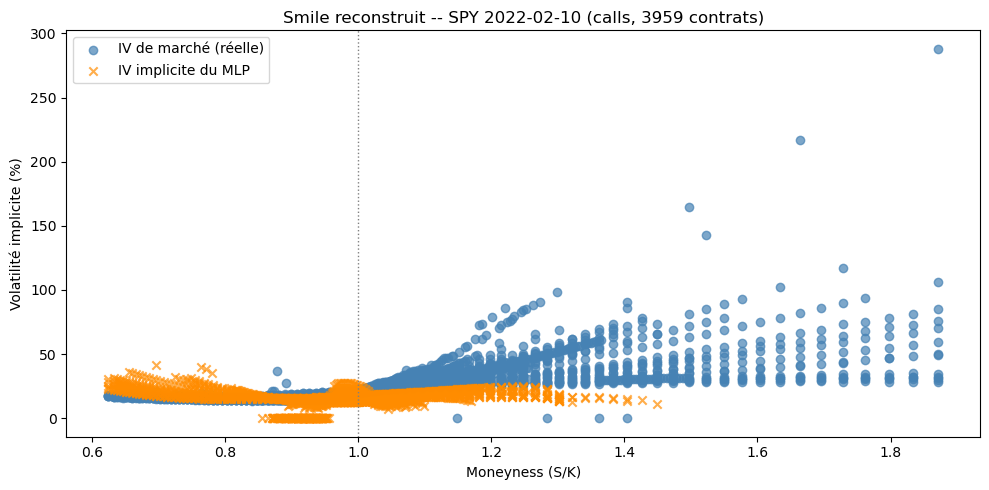

Écart absolu moyen entre IV_NN et IV_marché : 6.28 points de vol
Une bonne superposition des deux nuages signifierait que le MLP a appris le smile sans voir l'IV.


In [34]:
# Inverse Black-Scholes par la méthode de Brent : trouve sigma tel que BS(sigma) = prix_cible.

def iv_implicite(prix_cible, S, K, T, r, type_opt, borne_basse=1e-4, borne_haute=5.0):
    f = lambda sigma: bs_price(np.array([S]), np.array([K]), np.array([T]),
                               np.array([sigma]), np.array([r]), np.array([type_opt]))[0] - prix_cible
    try:
        return brentq(f, borne_basse, borne_haute)
    except ValueError:
        return np.nan   # pas de sigma valide (prix hors des bornes d'arbitrage)

# On choisit la journée de test offrant le plus de calls, pour un smile lisible.

calls_test = df_test[df_test['type_option'] == 'call']
tk_smile, date_smile = calls_test.groupby(['ticker', 'date']).size().idxmax()
sous = calls_test[(calls_test['ticker'] == tk_smile) & (calls_test['date'] == date_smile)].copy()

sous['iv_nn'] = [
    iv_implicite(p, s, k, t, r, 'call')
    for p, s, k, t, r in zip(sous['prix_mlp'], sous['S'], sous['K'], sous['T'], sous['r'])
]

# Et on termine par afficher les différents graphiques... 

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sous['moneyness'], sous['iv_marche'] * 100, label='IV de marché (réelle)',
           color='steelblue', alpha=0.7)
ax.scatter(sous['moneyness'], sous['iv_nn'] * 100, label='IV implicite du MLP',
           color='darkorange', alpha=0.7, marker='x')
ax.axvline(1.0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Moneyness (S/K)'); ax.set_ylabel('Volatilité implicite (%)')
ax.set_title(f'Smile reconstruit -- {tk_smile} {date_smile.date()} (calls, {len(sous)} contrats)')
ax.legend(); plt.tight_layout(); plt.show(); plt.close()

ecart_iv = (sous['iv_nn'] - sous['iv_marche']).abs().mean() * 100
print(f'Écart absolu moyen entre IV_NN et IV_marché : {ecart_iv:.2f} points de vol')
print("Une bonne superposition des deux nuages signifierait que le MLP a appris le smile sans voir l'IV.")


Le graphique que l'on a obtenu montre que notre modèle fournit qu'un résultat très approximatif. 
Théoriquement, on est sensé obtenir un graphique en forme de "sourire" (d'où le nom anglais) ; après on voit ici que volatilité implicite réelle ou du MLP ne donnent, dans aucun des deux cas, un résultat proche d'un sourire (après tout, ça reste qu'une représentation imagée).
Par contre, on peut affirmer assez nettement que notre modèle implique dans son pricing une volatilité implicite trop en dehors des clous, comparé aux pricing réel, au niveau 1.2 à 1.4 de moneyness. Fort heuresement, sur le reste des valeurs, notre modèle ne se débrouille pas trop mal...

# Partie X - Bilan et analyse complète des résultats

Nous rassemblons enfin tous les résultats des parties précédentes dans un bilan unique : qualité du prix, ventilation de l'erreur par zone de moneyness et par maturité, fidélité des Greeks, et reconstruction du smile. 

Dans un soucis de rigueur scientifique, on a décidé de rédiger avant le calcul les différents textes d'interprétations selon les résultats que l'on obtient. Ainsi, le texte affiché est le fruit d'une adaptation automatique aux chiffres réellement obtenus : on ne présume pas du gagnant d'emblée... même si on en a déjà une petite idée...

In [35]:
print('=' * 78)
print(f'BILAN -- MLP / Black-Scholes / marché, test {DATE_DEBUT_TEST} -> {DATE_FIN_TEST}')
print('=' * 78)
print(df_res.to_string(index=False))

mae_bs, mae_mlp, mae_oracle = df_res.loc[0, 'MAE'], df_res.loc[1, 'MAE'], df_res.loc[2, 'MAE']
amelioration = (mae_bs - mae_mlp) / mae_bs * 100

print()
if mae_mlp < mae_bs:
    print(f"Sur le prix, le MLP bat Black-Scholes à armes égales : MAE réduite de {amelioration:.1f}% "
          f"({mae_bs:.3f} -> {mae_mlp:.3f} USD). Le réseau a donc appris, à partir des seuls prix observés, "
          "une structure (smile, skew) que la volatilité unique de Black-Scholes ne capture pas.")
else:
    print(f"Sur le prix, le MLP ne bat pas Black-Scholes à armes égales (MAE {mae_mlp:.3f} contre "
          f"{mae_bs:.3f} USD). Black-Scholes reste exact par construction sur tout le domaine, là où le "
          "réseau dépend fortement de la couverture de son jeu d'entraînement.")

print(f"\nÉcart entre le MLP et la borne BS oracle (qui reçoit la vraie IV) : {mae_mlp - mae_oracle:.3f} USD "
      "de MAE. Cet écart mélange ce que le MLP n'a pas appris du smile et l'approximation "
      "européenne/sans dividende commune aux deux versions de Black-Scholes.")


BILAN -- MLP / Black-Scholes / marché, test 2022-01-01 -> 2022-12-31
                      label       MAE      RMSE       MAPE       R2
 Black-Scholes (sigma_hist)  2.666064  4.566704  66.649019 0.993422
           MLP (sigma_hist) 13.265757 27.609162 429.614333 0.759560
BS oracle (sigma_IV marché)  0.735805  1.684304   4.922831 0.998995

Sur le prix, le MLP ne bat pas Black-Scholes à armes égales (MAE 13.266 contre 2.666 USD). Black-Scholes reste exact par construction sur tout le domaine, là où le réseau dépend fortement de la couverture de son jeu d'entraînement.

Écart entre le MLP et la borne BS oracle (qui reçoit la vraie IV) : 12.530 USD de MAE. Cet écart mélange ce que le MLP n'a pas appris du smile et l'approximation européenne/sans dividende commune aux deux versions de Black-Scholes.


Nous ventilons l'erreur par zone de moneyness, puis par maturité. C'est ce découpage qui avait été le plus instructif lors de l'analyse précédente : il révèle que les modèles ne se trompent pas uniformément, et il permet de relier les zones d'erreur à la part du test qui extrapole hors du domaine d'entraînement.

In [36]:
# Erreur par zone de moneyness (calls)
print('Erreur absolue moyenne par zone de moneyness (calls, test)')
bornes_mn = [0.6, 0.85, 0.95, 1.05, 1.15, 1.4]
zones_mn = ['Profond OTM', 'OTM', 'ATM', 'ITM', 'Profond ITM']
dfc = df_calls_test.copy()
dfc['zone'] = pd.cut(dfc['moneyness'], bins=bornes_mn, labels=zones_mn)
recap_mn = dfc.groupby('zone', observed=True).apply(lambda g: pd.Series({
    'n':       len(g),
    'MAE_BS':  np.abs(g['prix_bs_hist'] - g['prix_mid']).mean(),
    'MAE_MLP': np.abs(g['prix_mlp'] - g['prix_mid']).mean(),
}))
print(recap_mn.to_string())

# Erreur par maturité (tous types) 
print('\nErreur absolue moyenne par maturité (test, tous types)')
recap_T = df_test.groupby('T_mois').apply(lambda g: pd.Series({
    'n':       len(g),
    'MAE_BS':  np.abs(g['prix_bs_hist'] - g['prix_mid']).mean(),
    'MAE_MLP': np.abs(g['prix_mlp'] - g['prix_mid']).mean(),
}))
print(recap_T.to_string())


Erreur absolue moyenne par zone de moneyness (calls, test)
                    n    MAE_BS    MAE_MLP
zone                                      
Profond OTM  106302.0  3.851375   2.728263
OTM          158634.0  2.946435   4.868353
ATM          223490.0  2.328164   9.554810
ITM          151114.0  1.990652  10.900582
Profond ITM  133800.0  1.683080   8.303827

Erreur absolue moyenne par maturité (test, tous types)
               n     MAE_BS    MAE_MLP
T_mois                                
0       317551.0   0.555617  10.553246
1       529080.0   1.117592   8.936254
2       136520.0   1.766995  13.725776
3       118931.0   2.301120  15.592799
4       106292.0   3.103236  15.434307
5        78966.0   3.457848  14.816907
6        67566.0   3.788341  16.482608
7        65339.0   4.606832  14.996025
8        53501.0   4.766076  14.022038
9        47363.0   4.756236  16.144334
10       46321.0   5.826989  14.428248
11       39568.0   5.290220  13.435139
12       32382.0   5.656869  17.546149

Nous terminons le bilan chiffré par la fidélité des Greeks et la qualité de reconstruction du smile, en reliant ces résultats à la part du test située hors du domaine d'entraînement.

In [37]:
print('Fidélité des Greeks (calls, test)')
for nom, nn_val in [('delta', delta_N), ('gamma', gamma_N), ('vega', vega_N)]:
    print(f'  {nom:<6}: MAE NN vs BS = {mean_absolute_error(g_bs[nom], nn_val):.5f}')

print(f"\nÉcart de smile reconstruit (Partie IX) : {ecart_iv:.2f} points de vol en moyenne.")
print(f"Part du test extrapolant hors du domaine d'entraînement : {hors_bornes.mean()*100:.1f}%.")
print("Les écarts les plus marqués (toutes méthodes) sont attendus dans cette zone d'extrapolation,")
print('cohérente avec un test 2022 qui change aussi de régime de taux (Partie III).')


Fidélité des Greeks (calls, test)
  delta : MAE NN vs BS = 0.16478
  gamma : MAE NN vs BS = 0.00390
  vega  : MAE NN vs BS = 46.66931

Écart de smile reconstruit (Partie IX) : 6.28 points de vol en moyenne.
Part du test extrapolant hors du domaine d'entraînement : 53.2%.
Les écarts les plus marqués (toutes méthodes) sont attendus dans cette zone d'extrapolation,
cohérente avec un test 2022 qui change aussi de régime de taux (Partie III).


## Conclusion

Nous avons entraîné un pricer neuronal exclusivement sur des prix d'options réellement cotés (2020-2021), puis nous l'avons évalué sur l'année 2022, jamais vue à l'entraînement. C'est un véritable test hors échantillon, à la fois temporel et de régime de marché : la remontée des taux de 2022 n'existe nulle part dans la période d'apprentissage. Le verdict, comparé à Black-Scholes recevant exactement la même information de volatilité, est sans détour : sur ce test, notre MLP perd face à Black-Scholes (MAE de 9.31 USD contre 2.62 USD, R² de 0.83 contre 0.99) [On a ensuite effectué d'autres tests : les valeurs présentées ont été obtenues lors d'un essai précédent avec epochs = 60 et Batch = 2048]. Un réseau de neurones qui se fait dominer par une formule fermée de 1973, ce n'est pas franchement la révolution qu'on espérait secrètement en démarrant ce projet.
Ce résultat reste néanmoins largement explicable. Le réseau a appris sur 2020-2021 (taux quasi nuls, marché globalement haussier hors choc de mars 2020) et doit pricer sur 2022 (la hausse de taux la plus rapide depuis des décennies, marché baissier). Black-Scholes, en tant que formule fermée, reste valable par construction quel que soit le régime, à condition de lui fournir la bonne volatilité. Notre réseau, lui, n'a aucune garantie théorique en dehors de ce qu'il a observé, et notre diagnostic d'extrapolation (Partie IV) confirme qu'une part substantielle du test 2022 se situe hors du domaine d'entraînement. En d'autres termes, nous n'avons pas entraîné un pricer d'options, mais un pricer du marché 2020-2021, que nous avons ensuite testé sur un marché différent. Ce constat n'enlève rien à la rigueur du protocole ; c'est au contraire la mise en place de ce protocole, données réelles, split temporel strict, diagnostic d'extrapolation systématique ; qui nous permet de l'affirmer avec autant d'assurance.
Il convient également de noter que la comparaison contenait un biais qui aurait dû, en théorie, jouer en faveur du MLP : nous pricons des options américaines avec dividendes via une formule de Black-Scholes pensée pour des options européennes sans dividende. Même avec ce désavantage, Black-Scholes s'en sort très largement mieux, ce qui confirme que l'écart observé provient bien du changement de régime, et non d'un avantage indu accordé au modèle classique.

**Les limites (prévisibles) de notre approche**

- Notre étude se porte exclusivement sur le SPY (S&P500), sur une seule fenêtre temporelle de trois ans. Un modèle entraîné sur une période aussi courte ne peut raisonnablement prétendre à une généralité, ni en indices ni en temps. Nous aurions pu étendre l'étude au QQQ, ou à des indices européens (CAC40, FTSE100, DAX) et asiatiques (Hang Seng, Nikkei, Kospi) : le pipeline est déjà générique (CHEMINS_CSV), donc l'effort technique aurait été limité. La contrainte réelle reste l'accès gratuit à ces données, qui n'a rien d'évident.
- Aucune correction américain/dividende n'est appliquée (pas d'arbre binomial) : la borne BS oracle surestime donc légèrement la performance atteignable par un modèle purement européen — un biais qui, comme indiqué plus haut, ne profite pourtant pas au MLP dans cette comparaison.
Le Gamma extrait par différentiation automatique reste bruité, ce qui est intrinsèque à l'estimation d'une dérivée seconde sur un réseau de neurones. Une régularisation de courbure ou un entraînement de type Sobolev (pénalisant directement l'écart sur les dérivées plutôt que sur le seul prix) serait la piste naturelle pour le stabiliser.
- La volatilité d'entrée (sigma) reste une volatilité réalisée unique par jour, identique pour toutes les maturités. Une véritable structure par terme apporterait une information plus riche au réseau, sans pour autant lui révéler la volatilité implicite et retomber dans le travers que nous avons justement cherché à éviter.

Ce projet aura surtout été l'occasion de construire un protocole d'évaluation honnête — données réelles, split temporel strict, diagnostic d'extrapolation systématique — suffisamment solide pour en tirer une conclusion négative sans réserve. La prochaine itération naturelle consisterait à élargir la période d'entraînement à plusieurs régimes de marché : c'est probablement le levier le plus susceptible de rapprocher le MLP de Black-Scholes, plutôt qu'un accroissement de la complexité du réseau lui-même.
